In [11]:
# %matplotlib widget

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns



In [12]:
df = pd.read_csv("../DATA/Anthocyanin_RND2.csv")
df.columns = df.columns.str.rstrip()
df = df.map(lambda x: x.rstrip() if isinstance(x, str) else x)
df.head(1)

,Lettuce color,DATE,catalog id,Illumination,Leaf sample weight in grams,Sample circle weight - grams,Anthocyanin OD-530nm,Chlorophyll OD-657nm,Chlorophyll interference,Anthocyanin
0,R,22/01/2026,R1,White+Blue LED,0.28,0.03,0.3925,0.33,0.083,0.31


In [13]:
df.columns

Index(['Lettuce color', 'DATE', 'catalog id', 'Illumination',
       'Leaf sample weight in grams', 'Sample circle weight - grams',
       'Anthocyanin OD-530nm', 'Chlorophyll OD-657nm',
       'Chlorophyll interference', 'Anthocyanin'],
      dtype='str')

In [14]:
df['DATE'] = pd.to_datetime(df['DATE'], format='%d/%m/%Y')
df_red=df[df['Lettuce color'] == 'R']
df_green=df[df['Lettuce color'] == 'G']

In [15]:
df_red_without_neg=df_red[df_red['Anthocyanin'] > 0]

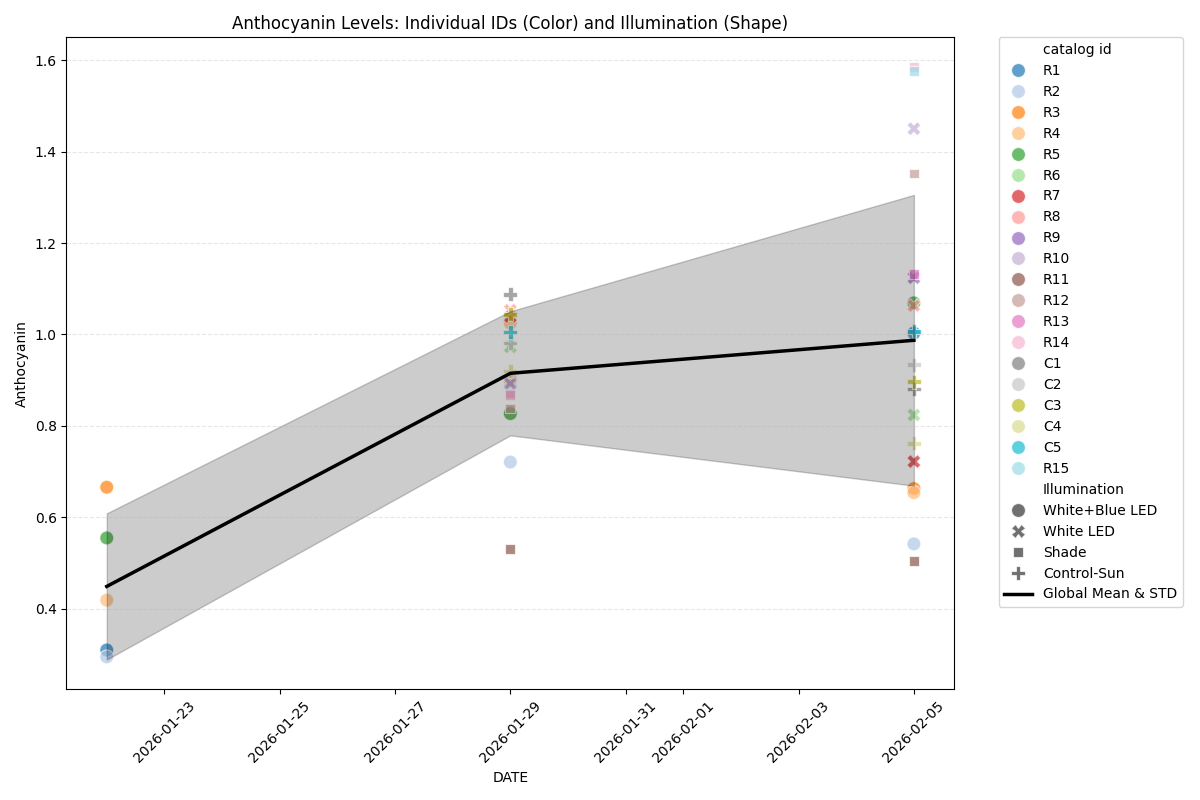

In [23]:


# 1. Create the figure
plt.figure(figsize=(12, 8)) # Increased height slightly for the long legend

# 2. Draw the Scatter Plot
# hue: Individual plant IDs (Colors)
# style: Broad light categories (Shapes)
sns.scatterplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    hue='catalog id',      # Colors represent individual plants
    style='Illumination',  # Shapes represent the light group
    palette='tab20',       # Best for 20 distinct IDs
    alpha=0.7,
    s=100,                 # Size of the dots
    edgecolor='w'          # Thin white edge to separate overlapping points
)

# 3. Draw the Mean + STD line on top
# This gives you the global trend across all IDs
sns.lineplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    color='black', 
    errorbar='sd', 
    linewidth=2.5,
    label='Global Mean & STD',
    zorder=10             # Ensures the line stays on top of the dots
)

# 4. Move the legend
# Since you have 20 IDs + 4 Shapes, the legend will be very tall
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., ncol=1)

plt.title('Anthocyanin Levels: Individual IDs (Color) and Illumination (Shape)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3) # Added a light grid for easier reading
plt.tight_layout()
plt.show()

In [ ]:
# 1. Create the figure
plt.figure(figsize=(12, 6))

# 2. Draw the Scatter Plot with Seaborn
# 'hue' handles the colors and creates the legend automatically
sns.scatterplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    hue='Illumination', 
    palette='Set1', 
    alpha=0.6,
    edgecolor=None
)

# 3. Draw the Mean + STD line on top
sns.lineplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    color='black', 
    errorbar='sd', 
    label='Mean & STD (Global)'
)

# 4. Move the legend so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title('Anthocyanin Levels by Illumination')
plt.tight_layout() # Prevents the legend from being cut off
plt.show()

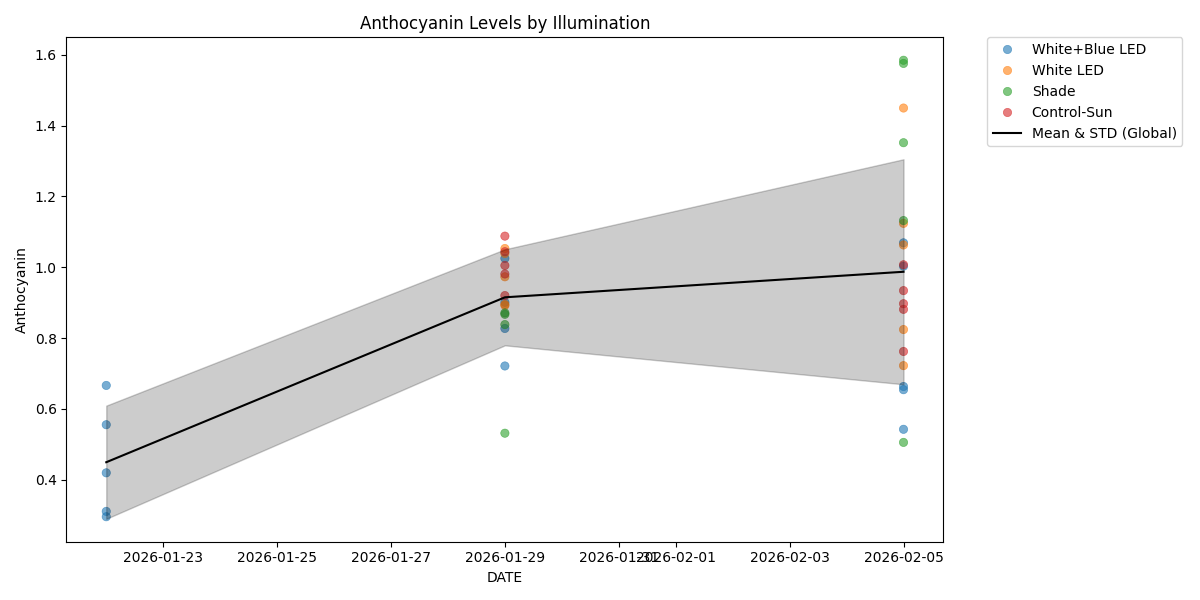

In [17]:


# 1. Create the figure
plt.figure(figsize=(12, 6))

# 2. Draw the Scatter Plot with Seaborn
# 'hue' handles the colors and creates the legend automatically
sns.scatterplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    hue='Illumination', 
    palette='tab10', 
    alpha=0.6,
    edgecolor=None
)

# 3. Draw the Mean + STD line on top
sns.lineplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    color='black', 
    errorbar='sd', 
    label='Mean & STD (Global)'
)

# 4. Move the legend so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title('Anthocyanin Levels by Illumination')
plt.tight_layout() # Prevents the legend from being cut off
plt.show()

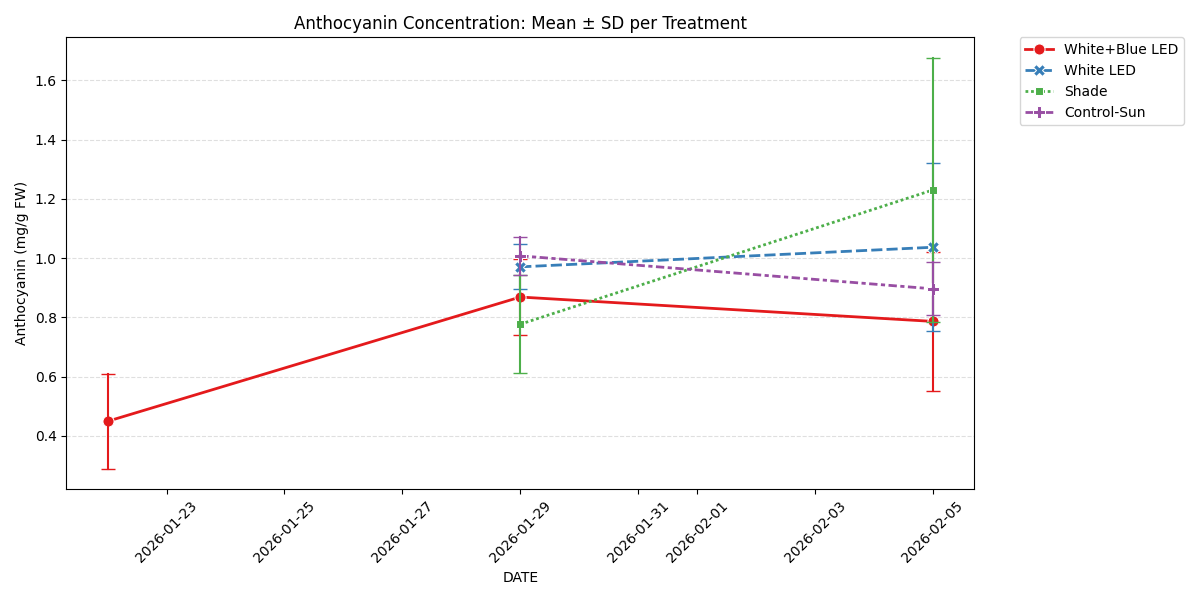

In [24]:


plt.figure(figsize=(12, 6))

# Use err_kws to pass capsize to the underlying errorbar function
sns.lineplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    hue='Illumination', 
    style='Illumination',
    markers=True,         
    errorbar='sd',        
    err_style='bars',     
    err_kws={'capsize': 5},  # This is the fix!
    palette='Set1',
    linewidth=2,
    markersize=8
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Anthocyanin Concentration: Mean ± SD per Treatment')
plt.ylabel('Anthocyanin (mg/g FW)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

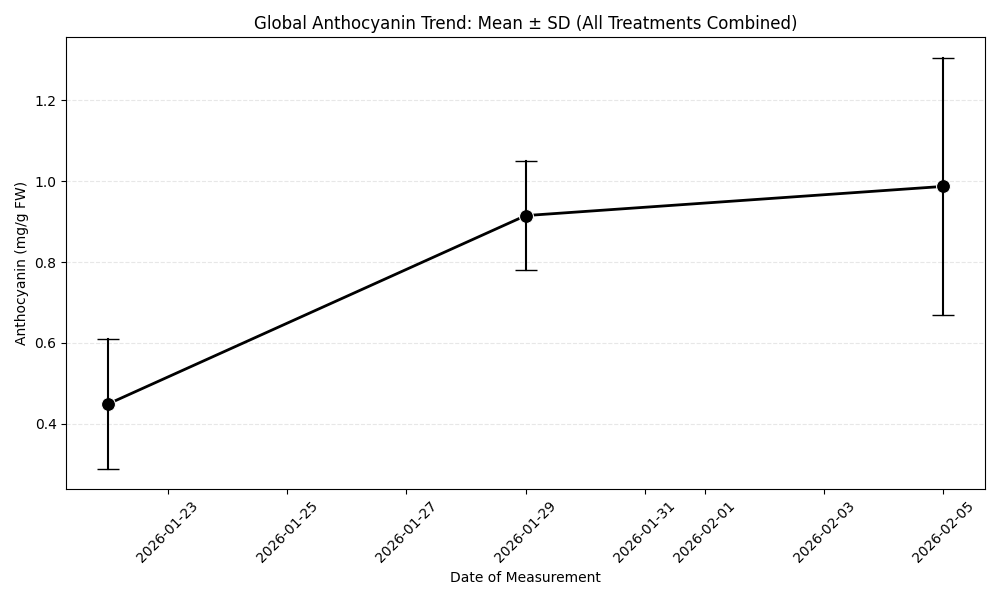

In [25]:


# 1. Create the figure
plt.figure(figsize=(10, 6))

# 2. Draw the Global Error Bar Plot
# By removing 'hue', we force Seaborn to aggregate ALL treatments together
sns.lineplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    marker='o',           # Adds a single dot for the global mean
    errorbar='sd',        # Calculates the SD of all samples on that date
    err_style='bars',     # Shows the "I" bars
    err_kws={'capsize': 8}, 
    color='black',        # A neutral color for global data
    linewidth=2,
    markersize=10
)

# 3. Formatting
plt.title('Global Anthocyanin Trend: Mean ± SD (All Treatments Combined)')
plt.ylabel('Anthocyanin (mg/g FW)')
plt.xlabel('Date of Measurement')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# 1. Group by DATE
# 2. Pick the column 'Anthocyanin'
# 3. Aggregate by 'mean' and 'std'
stats_df = df_red_without_neg.groupby('DATE')['Anthocyanin'].agg(['mean', 'std']).reset_index()

# Display the result
print(stats_df)

        DATE      mean       std
0 2026-01-22  0.449000  0.159892
1 2026-01-29  0.915056  0.135704
2 2026-02-05  0.987250  0.317958


In [19]:
# Group by two columns instead of one
detailed_stats = df_red_without_neg.groupby(['DATE', 'Illumination'])['Anthocyanin'].agg(['mean', 'std']).reset_index()

# This gives you a row for every unique Date-Illumination combination
# Sort by Illumination alphabetically
detailed_stats = detailed_stats.sort_values(by=['Illumination','DATE' ])

# Display the sorted result
print(detailed_stats)

        DATE    Illumination     mean       std
1 2026-01-29     Control-Sun  1.00760  0.063595
5 2026-02-05     Control-Sun  0.89620  0.089368
2 2026-01-29           Shade  0.77675  0.164492
6 2026-02-05           Shade  1.23000  0.446053
3 2026-01-29       White LED  0.97040  0.076432
7 2026-02-05       White LED  1.03660  0.284345
0 2026-01-22  White+Blue LED  0.44900  0.159892
4 2026-01-29  White+Blue LED  0.86850  0.127837
8 2026-02-05  White+Blue LED  0.78620  0.234130


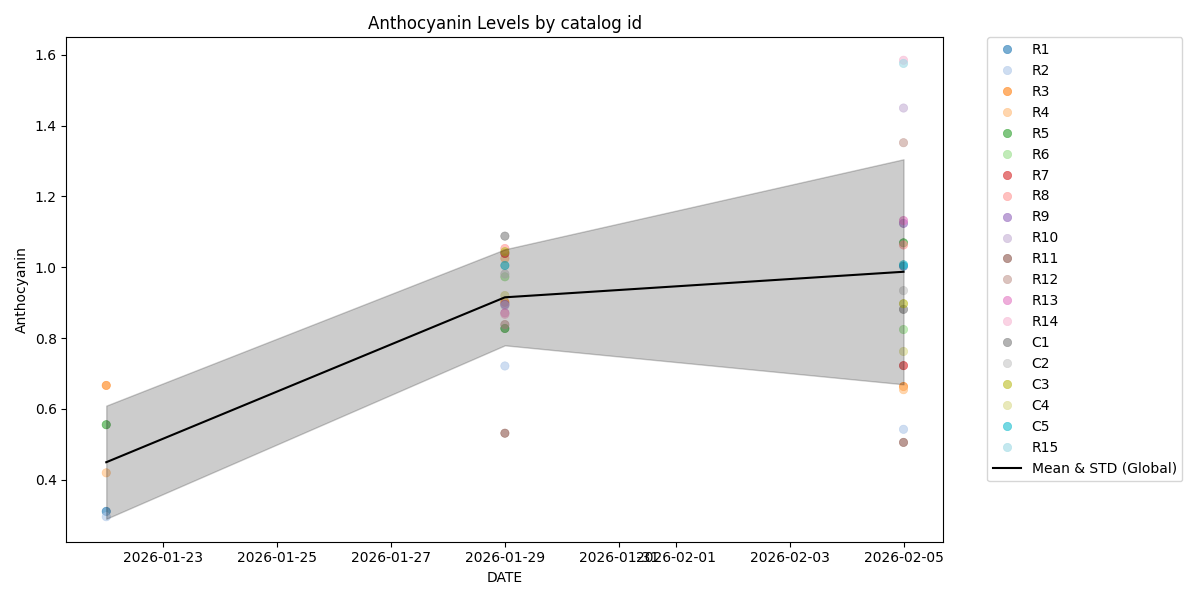

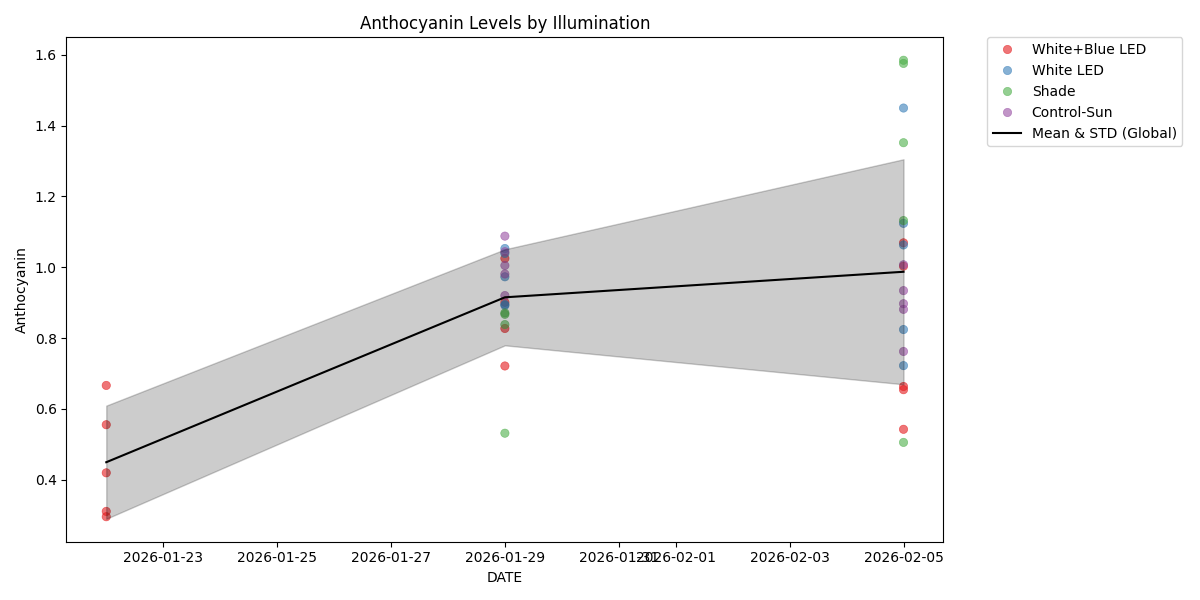

In [20]:



# 1. Create the figure
plt.figure(figsize=(12, 6))

# 2. Draw the Scatter Plot with Seaborn
# 'hue' handles the colors and creates the legend automatically
sns.scatterplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    hue='catalog id', 
    palette='tab20', 
    alpha=0.6,
    edgecolor=None
)

# 3. Draw the Mean + STD line on top
sns.lineplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    color='black', 
    errorbar='sd', 
    label='Mean & STD (Global)'
)

# 4. Move the legend so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title('Anthocyanin Levels by catalog id')
plt.tight_layout() # Prevents the legend from being cut off
plt.show()

#########################################################


# 1. Create the figure
plt.figure(figsize=(12, 6))

# 2. Draw the Scatter Plot with Seaborn
# 'hue' handles the colors and creates the legend automatically
sns.scatterplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    hue='Illumination', 
    palette='Set1', 
    alpha=0.6,
    edgecolor=None
)

# 3. Draw the Mean + STD line on top
sns.lineplot(
    data=df_red_without_neg, 
    x='DATE', 
    y='Anthocyanin', 
    color='black', 
    errorbar='sd', 
    label='Mean & STD (Global)'
)

# 4. Move the legend so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title('Anthocyanin Levels by Illumination')
plt.tight_layout() # Prevents the legend from being cut off
plt.show()

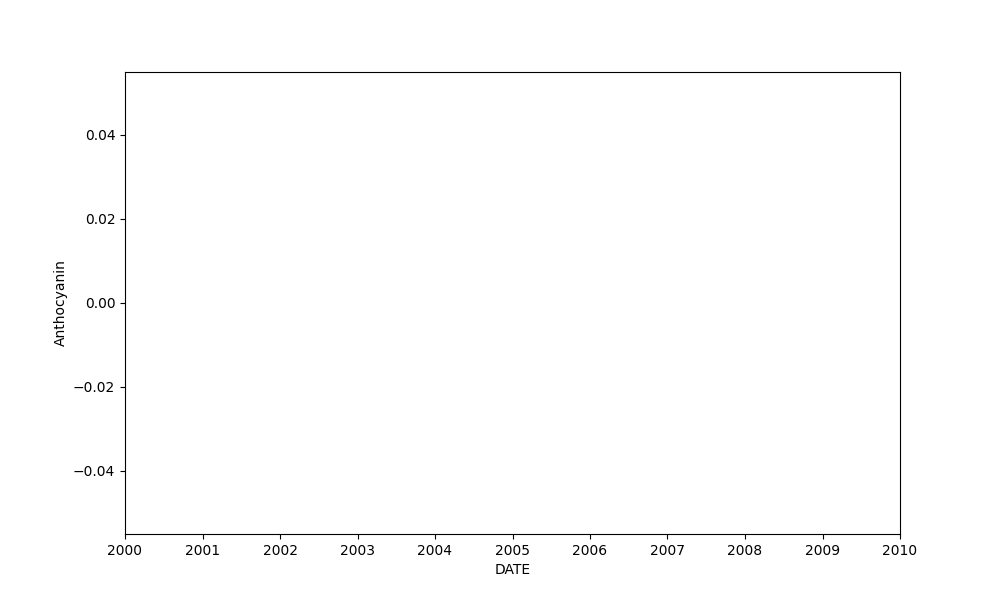

In [21]:
df_green=df[df['Lettuce color'] == 'GREEN']
#plt.figure(figsize=(10, 6))
#df_green.plot.scatter(x='DATE', y='Anthocyanin', title='Anthocyanin level along the dates')

df_green.plot.scatter(x='DATE', y='Anthocyanin', 
        c='Illumination', 
        colormap='Set1',figsize=(10, 6) ,
        sharex=False)          

plt.show()